# **Data importing and data standardization and correlation heat map**

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import copy


train = pd.read_excel("BNT-Energy2f.xlsx")
X=train.iloc[:,:-1]
Y=train.iloc[:,-1]

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=42)


scalerX = StandardScaler().fit(X_train)
scalery = StandardScaler().fit(y_train.values.reshape(-1,1))
X_train1 = scalerX.transform(X_train)
y_train1 = scalery.transform(y_train.values.reshape(-1,1))
X_test1 = scalerX.transform(X_test)
y_test1 = scalery.transform(y_test.values.reshape(-1,1))
y_new_inverse = scalery.inverse_transform(y_test1.reshape(-1,1))
X_train2=copy.deepcopy(X_train1)
y_train2=copy.deepcopy(y_train1)


from sklearn.linear_model import ElasticNet, Lasso, LinearRegression
from xgboost import XGBRegressor
# from sklearn.base import BaseEstimator, TransformerMixin, RegressorMixin, clone
from sklearn.model_selection import KFold, cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error,r2_score,mean_squared_error

xgb_model=XGBRegressor()

search_space={'n_estimators':[100,200,300,400,500,600,800],'max_depth':[3,4,6,7,9],'gamma0':[0.01],'learning_rate':[0.001,0.01,0.05,0.1,0.5,1]}


from sklearn.model_selection import GridSearchCV

GS=GridSearchCV(estimator=xgb_model,param_grid=search_space,scoring=["r2","neg_root_mean_squared_error"],refit="neg_root_mean_squared_error",cv=5,verbose=4)
GS.fit(X_train1,y_train1)

print(GS.best_params_) # ND gamma0=0.01, learning_rate=0.01, max_depth=9, n_estimators=800;
print(GS.best_score_)
from sklearn.metrics import r2_score
model_xgb=XGBRegressor(n_estimators=600,max_depth=4,eta=0.1)
model_xgb.fit(X_train1,y_train1)
#y_pred=model_xgb.predict(X_test1)

#y_new_inverse = scalery.inverse_transform(y_pred.reshape(-1,1))
#Y_true=scalery.inverse_transform(y_test1)
#r2_score(Y_true,y_new_inverse)

Fitting 5 folds for each of 210 candidates, totalling 1050 fits
[CV 1/5] END gamma0=0.01, learning_rate=0.001, max_depth=3, n_estimators=100; neg_root_mean_squared_error: (test=-0.792) r2: (test=0.143) total time=   0.1s
[CV 2/5] END gamma0=0.01, learning_rate=0.001, max_depth=3, n_estimators=100; neg_root_mean_squared_error: (test=-1.019) r2: (test=0.139) total time=   0.1s
[CV 3/5] END gamma0=0.01, learning_rate=0.001, max_depth=3, n_estimators=100; neg_root_mean_squared_error: (test=-0.978) r2: (test=0.144) total time=   0.1s


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [08:38:50] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "gamma0" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [08:38:50] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "gamma0" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [08:38:50] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "gamma0" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [08:38:50] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "gamma0" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV 4/5] END gamma0=0.01, learning_rate=0.001, max_depth=3, n_estimators=100; neg_root_mean_squared_error: (test=-0.763) r2: (test=0.147) total time=   0.1s
[CV 5/5] END gamma0=0.01, learning_rate=0.001, max_depth=3, n_estimators=100; neg_root_mean_squared_error: (test=-1.042) r2: (test=0.126) total time=   0.1s
[CV 1/5] END gamma0=0.01, learning_rate=0.001, max_depth=3, n_estimators=200; neg_root_mean_squared_error: (test=-0.726) r2: (test=0.279) total time=   0.1s


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [08:38:50] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "gamma0" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [08:38:50] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "gamma0" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [08:38:50] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "gamma0" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV 2/5] END gamma0=0.01, learning_rate=0.001, max_depth=3, n_estimators=200; neg_root_mean_squared_error: (test=-0.938) r2: (test=0.271) total time=   0.1s
[CV 3/5] END gamma0=0.01, learning_rate=0.001, max_depth=3, n_estimators=200; neg_root_mean_squared_error: (test=-0.905) r2: (test=0.267) total time=   0.1s
[CV 4/5] END gamma0=0.01, learning_rate=0.001, max_depth=3, n_estimators=200; neg_root_mean_squared_error: (test=-0.703) r2: (test=0.275) total time=   0.1s


...

[CV 4/5] END gamma0=0.01, learning_rate=0.001, max_depth=3, n_estimators=800; neg_root_mean_squared_error: (test=-0.464) r2: (test=0.685) total time=   0.4s


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [08:38:57] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "gamma0" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV 5/5] END gamma0=0.01, learning_rate=0.001, max_depth=3, n_estimators=800; neg_root_mean_squared_error: (test=-0.705) r2: (test=0.599) total time=   0.8s


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [08:38:58] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "gamma0" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


KeyboardInterrupt: 

# **Model defining and training and best parameters with performance metric**


# **Model Prediction and plot with error bars using bootstrapping**

In [6]:
Li = pd.read_excel("RSD.xlsx")
X_test=Li.iloc[:,:-1]
Y_test=Li.iloc[:,-1]

X_test1 = scalerX.transform(X_test)
Y_test1 = scalery.transform(Y_test.values.reshape(-1,1))


from sklearn.metrics import mean_squared_error

bootstrap_means=[]


N=500

for i in range(0,N):
  sample_index=np.random.choice(range(0,len(y_train1)),len(y_train1))

  X_samples=X_train1[sample_index]
  y_samples=y_train1[sample_index]
  print(i)

  model_xgb=XGBRegressor(n_estimators=800,max_depth=3,eta=0.01) #change parameters according to the best fit you achieved at the top!
  model_xgb.fit(X_samples, y_samples)
  y_prediction=model_xgb.predict(X_test1)


  bootstrap_means.append(scalery.inverse_transform(y_prediction.reshape(-1,1)))


bootstrap_means_array=np.array(bootstrap_means)


# Define file names for training and testing data
test_file = 'test_data_output_final.xlsx'

# Save the testing data to an Excel file
test_data_output_final = pd.concat([X_test, Y_test], axis=1)
test_data_output_final.to_excel(test_file, index=False)

# Add predictions to the 'test' DataFrame
test_data_output_final['Predicted_W'] = bootstrap_means_array.mean(0)
test_data_output_final['Error'] = bootstrap_means_array.std(0)

# Save the updated DataFrame with predictions to a new file
output_file = 'test_predicted_W.xlsx.'  # Update with the desired output file path
test_data_output_final.to_excel('test_predicted_W-newfeature-IE.xlsx', index=False)


print(mean_squared_error(scalery.inverse_transform(Y_test1),bootstrap_means_array.mean(0)))
print(np.sqrt(mean_squared_error(scalery.inverse_transform(Y_test1),bootstrap_means_array.mean(0))))





0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

In [ ]:
print(scalery.inverse_transform(Y_test1))
print(bootstrap_means_array.mean(0))

np.savetxt("XGB-d33-Test-Series-Sb.csv", scalery.inverse_transform(Y_test1), delimiter=",")
np.savetxt("XGB-d33-prediction-series-Sb.csv", bootstrap_means_array.mean(0), delimiter=",")
np.savetxt("XGB-d33-std-series-Sb.csv", bootstrap_means_array.std(0), delimiter=",")

[[0.06 ]
 [0.497]
 [0.5  ]
 [0.342]
 [0.463]
 [0.467]
 [0.46 ]
 [1.7  ]
 [0.724]
 [0.555]
 [0.61 ]
 [0.512]
 [0.303]
 [0.381]
 [0.68 ]
 [0.25 ]
 [0.11 ]]
[[0.8623961 ]
 [0.5672113 ]
 [0.6195414 ]
 [0.7019051 ]
 [0.88120925]
 [0.8664459 ]
 [0.9070936 ]
 [1.7220861 ]
 [0.9709595 ]
 [1.1728642 ]
 [0.657219  ]
 [0.90042555]
 [0.8434225 ]
 [0.60923177]
 [0.94534564]
 [1.0791979 ]
 [1.0828006 ]]


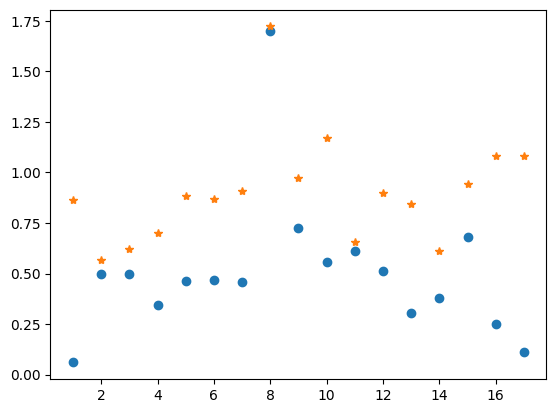

In [ ]:
X=range(1,len(scalery.inverse_transform(Y_test1))+1)
plt.plot(X,scalery.inverse_transform(Y_test1),'o')
plt.plot(X,bootstrap_means_array.mean(0),'*')
plt.show()

PB 0.00055340194
PA 0.0019609907
PAdB 0.0036515708
p 0.0026388108
ENAMB 0.00939943
ENBMB 0.007719278
EAdEB 0.0009674755
ENprod 0.0060529085
Ionic Radii A 0.0012482561
Ionic Radii B 0.008276237
RAdRB 0.0030289616
tAB-ionic 0.002282769
Tolerance Factor(Ionic) 0.0009219295
A site atomic Vol. (cm3) 0.0031552117
B site atomic Vol. (cm3) 0.023448445
VAdVB 0.002118804
VolProd 0.0067740097
NTC 0.74316204
Atomic Wt. Composition 0.014889231
Atomic No. Composition 0.013506033
Doping elements at. No. 0.010397229
Doping element at. wt. 0.02055081
A Site Dopant at wt 0.00068100233
B Site Dopant at wt 0.0
KP 0.0043639885
A site radius sum 0.00096818776
E 0.087708876
D33 0.019574104
[5.5340194e-04 1.9609907e-03 3.6515708e-03 2.6388108e-03 9.3994299e-03
 7.7192779e-03 9.6747553e-04 6.0529085e-03 1.2482561e-03 8.2762372e-03
 3.0289616e-03 2.2827690e-03 9.2192949e-04 3.1552117e-03 2.3448445e-02
 2.1188040e-03 6.7740097e-03 7.4316204e-01 1.4889231e-02 1.3506033e-02
 1.0397229e-02 2.0550810e-02 6.8100233e-

<Axes: >

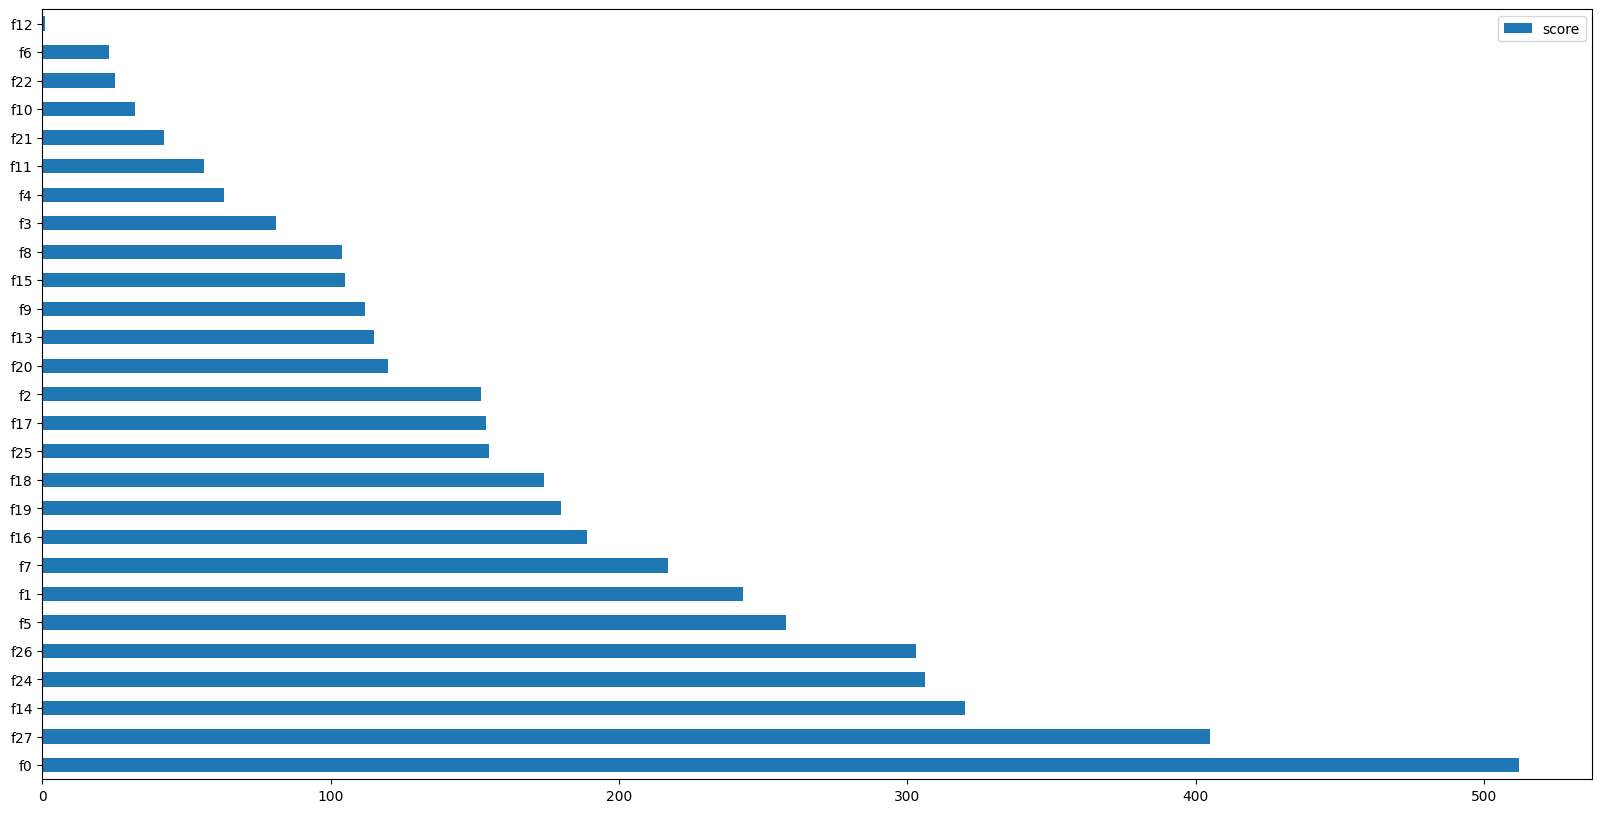

In [ ]:
from matplotlib import pyplot
from xgboost import XGBClassifier
from xgboost import plot_importance
import pandas as pd
dictionary={}
for col,score in zip(train.columns,model_xgb.feature_importances_):
    print(col,score)
    dictionary[col]=score


print(model_xgb.feature_importances_)
feature_important = model_xgb.get_booster().get_score(importance_type='weight')
keys = list(feature_important.keys())
values = list(feature_important.values())

data = pd.DataFrame(data=values, index=keys, columns=["score"]).sort_values(by = "score", ascending=True)
data.nlargest(40, columns="score").plot(kind='barh', figsize = (20,10)) ## plot top 40 features

In [ ]:
from collections import OrderedDict
import numpy as np

keys = list(dictionary.keys())
values = list(dictionary.values())
sorted_value_index = np.argsort(values)
sorted_dict = {keys[i]: values[i] for i in sorted_value_index}

print(sorted_dict)

{'B Site Dopant at wt': 0.0, 'PB': 0.00055340194, 'A Site Dopant at wt': 0.00068100233, 'Tolerance Factor(Ionic)': 0.0009219295, 'EAdEB': 0.0009674755, 'A site radius sum': 0.00096818776, 'Ionic Radii A': 0.0012482561, 'PA': 0.0019609907, 'VAdVB': 0.002118804, 'tAB-ionic': 0.002282769, 'p': 0.0026388108, 'RAdRB': 0.0030289616, 'A site atomic Vol. (cm3)': 0.0031552117, 'PAdB': 0.0036515708, 'KP': 0.0043639885, 'ENprod': 0.0060529085, 'VolProd': 0.0067740097, 'ENBMB': 0.007719278, 'Ionic Radii B': 0.008276237, 'ENAMB': 0.00939943, 'Doping elements at. No.': 0.010397229, 'Atomic No. Composition': 0.013506033, 'Atomic Wt. Composition': 0.014889231, 'D33': 0.019574104, 'Doping element at. wt.': 0.02055081, 'B site atomic Vol. (cm3)': 0.023448445, 'E': 0.087708876, 'NTC': 0.74316204}
